In [3]:
import matplotlib.pyplot as plt
import json
import os
import numpy as np
import pandas as pd
from tabulate import tabulate

In [4]:
PATH = "/home/ray/Documents/icccn-lstm/devs/lstm/"
TYPES = {"lstm": "LSTM", "gru": "GRU", "rnn": "SimpleRNN"}
RATS = {"dsrc": "DSRC", "pc5": "C-V2X PC5", "5g": "5G SA"}


In [5]:
def plot_losses(types, rats):

    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
    i, j = 0, 0

    for rat in rats:
        for type in types:
            with open(os.path.join(PATH, type + "_" + rat + "_training_history.json"), "r") as f:
                history = json.load(f)
                epochs = np.arange(len(history['loss']))  # Assuming loss has same length as RMSE

                ax = axes[i, j]
                twin_ax = ax.twinx()

                # Plot RMSE curves
                ax.plot(epochs, np.sqrt(history["latency_ms_rmse"]), label="Latency RMSE", color="blue", linestyle="-")
                ax.plot(epochs, np.sqrt(history["val_latency_ms_rmse"]), label="Val Latency RMSE", color="blue", linestyle="dashed")

                twin_ax.plot(epochs, np.sqrt(history["pdr_rmse"]), label="PDR RMSE", color="red", linestyle="-")
                twin_ax.plot(epochs, np.sqrt(history["val_pdr_rmse"]), label="Val PDR RMSE", color="red", linestyle="dashed")

                # Labels and formatting
                ax.set_title(rats[rat] + " - " + types[type])
                ax.set_xlabel("Epochs")
                ax.set_ylabel("Latency RMSE (ms)", color="black")
                twin_ax.set_ylabel("PDR RMSE (%)", color="black")

                ax.tick_params(axis='y', colors='black')
                twin_ax.tick_params(axis='y', colors='black')

                # Adjust PDR and Latency RMSE axis limits
                if rat == "5g":
                    twin_ax.set_ylim(0, 0.52)  # 5G SA PDR RMSE range
                    ax.set_ylim(0.4, 2)
                elif rat == "dsrc":
                    twin_ax.set_ylim(0, 0.52)  # DSRC & C-V2X PDR RMSE range
                    ax.set_ylim(0.04, 0.11)
                elif rat == "pc5":
                    twin_ax.set_ylim(0, 0.52)  # DSRC & C-V2X PDR RMSE range
                    ax.set_ylim(0.42, 0.52)

                # Legend
                ax.legend(loc="upper left", fontsize=8)
                twin_ax.legend(loc="upper right", fontsize=8)

            j += 1
        i += 1
        j= 0

    fig.suptitle("Training vs Validation Loss (RMSE)")
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(os.path.join(PATH,"training_loss_grid.png"), dpi=600)
    fig.show()


def table_epochs(types, rats):
    summary_data = []
    i, j = 0, 0

    for rat in rats:
        for type in types:
            file_idx = i * 3 + j  # Map row/col to file index
            df = pd.read_csv(os.path.join(PATH, type + "_" + rat + "_training_log.csv"))

            # Extract summary statistics
            pdr_train_loss_final = df["Train Loss (PDR)"].iloc[-1]
            pdr_val_loss_final = df["Val Loss (PDR)"].iloc[-1]
            pdr_train_rmse_final = df["Train RMSE (PDR)"].iloc[-1]
            pdr_val_rmse_final = df["Val RMSE (PDR)"].iloc[-1]

            pdr_best_idx = df["Val RMSE (PDR)"].idxmin()  # Best epoch (lowest val loss)
            pdr_best_val_loss = df["Val Loss (PDR)"].iloc[pdr_best_idx]
            pdr_best_val_rmse = df["Val RMSE (PDR)"].min()


            latency_train_loss_final = df["Train Loss (Latency)"].iloc[-1]
            latency_val_loss_final = df["Val Loss (Latency)"].iloc[-1]
            latency_train_rmse_final = df["Train RMSE (Latency)"].iloc[-1]
            latency_val_rmse_final = df["Val RMSE (Latency)"].iloc[-1]

            latency_best_idx = df["Val RMSE (Latency)"].idxmin()  # Best epoch (lowest val loss)
            latency_best_val_loss = df["Val Loss (Latency)"].iloc[latency_best_idx]
            latency_best_val_rmse = df["Val RMSE (Latency)"].min()

            best_epoch = df["Epoch"].iloc[latency_best_idx]
            avg_epoch_time = df["Time (seconds)"].mean()
            fastest_training_time = df["Time (seconds)"].min()
            total_training_time = df["Time (seconds)"].sum()
            max_epoch = df["Epoch"].max()


            # Store results
            summary_data.append([
                rat, type, max_epoch, best_epoch, latency_best_val_loss, latency_best_val_rmse,
                latency_train_loss_final, latency_val_loss_final, latency_train_rmse_final, latency_val_rmse_final,
                pdr_best_val_loss, pdr_best_val_rmse, pdr_train_loss_final, pdr_val_loss_final, pdr_train_rmse_final,
                pdr_val_rmse_final, avg_epoch_time, fastest_training_time, total_training_time
            ])

            j += 1
        i += 1
        j= 0

    # Create DataFrame
    summary_df = pd.DataFrame(summary_data, columns=[
        "RAT", "Model type", "Max Epoch", "Best Epoch", "Best Val Loss (Latency)", "Best Val RMSE (Latency)",
        "Train Loss (Latency)", "Val Loss (Latency)", "Train RMSE (Latency)", "Val RMSE (Latency)",
        "Best Val Loss (PDR)", "Best Val RMSE (PDR)", "Train Loss (PDR)", "Val Loss (PDR)", "Train RMSE (PDR)",
        "Val RMSE (PDR)", "Avg Epoch Time (s)", "Fastest Training Time (s)", "Total Training Time (s)"
    ])

    # Display nicely formatted table in Jupyter
    summary_df.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [{'selector': 'th', 'props': [('font-size', '12pt'), ('text-align', 'center')]}]
    )

    summary_df.to_csv(os.path.join(PATH, "epoch_summary_table.csv"), index=False)

    return summary_df



In [6]:
epoch_table = table_epochs(TYPES, RATS)
print(tabulate(epoch_table, headers="keys", tablefmt="github"))


|    | RAT   | Model type   |   Max Epoch |   Best Epoch |   Best Val Loss (Latency) |   Best Val RMSE (Latency) |   Train Loss (Latency) |   Val Loss (Latency) |   Train RMSE (Latency) |   Val RMSE (Latency) |   Best Val Loss (PDR) |   Best Val RMSE (PDR) |   Train Loss (PDR) |   Val Loss (PDR) |   Train RMSE (PDR) |   Val RMSE (PDR) |   Avg Epoch Time (s) |   Fastest Training Time (s) |   Total Training Time (s) |
|----|-------|--------------|-------------|--------------|---------------------------|---------------------------|------------------------|----------------------|------------------------|----------------------|-----------------------|-----------------------|--------------------|------------------|--------------------|------------------|----------------------|-----------------------------|---------------------------|
|  0 | dsrc  | lstm         |          24 |           19 |               1.04129e-05 |                0.00235662 |            2.57089e-05 |          1.07309e-05

/tmp/ipykernel_754647/1241543059.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


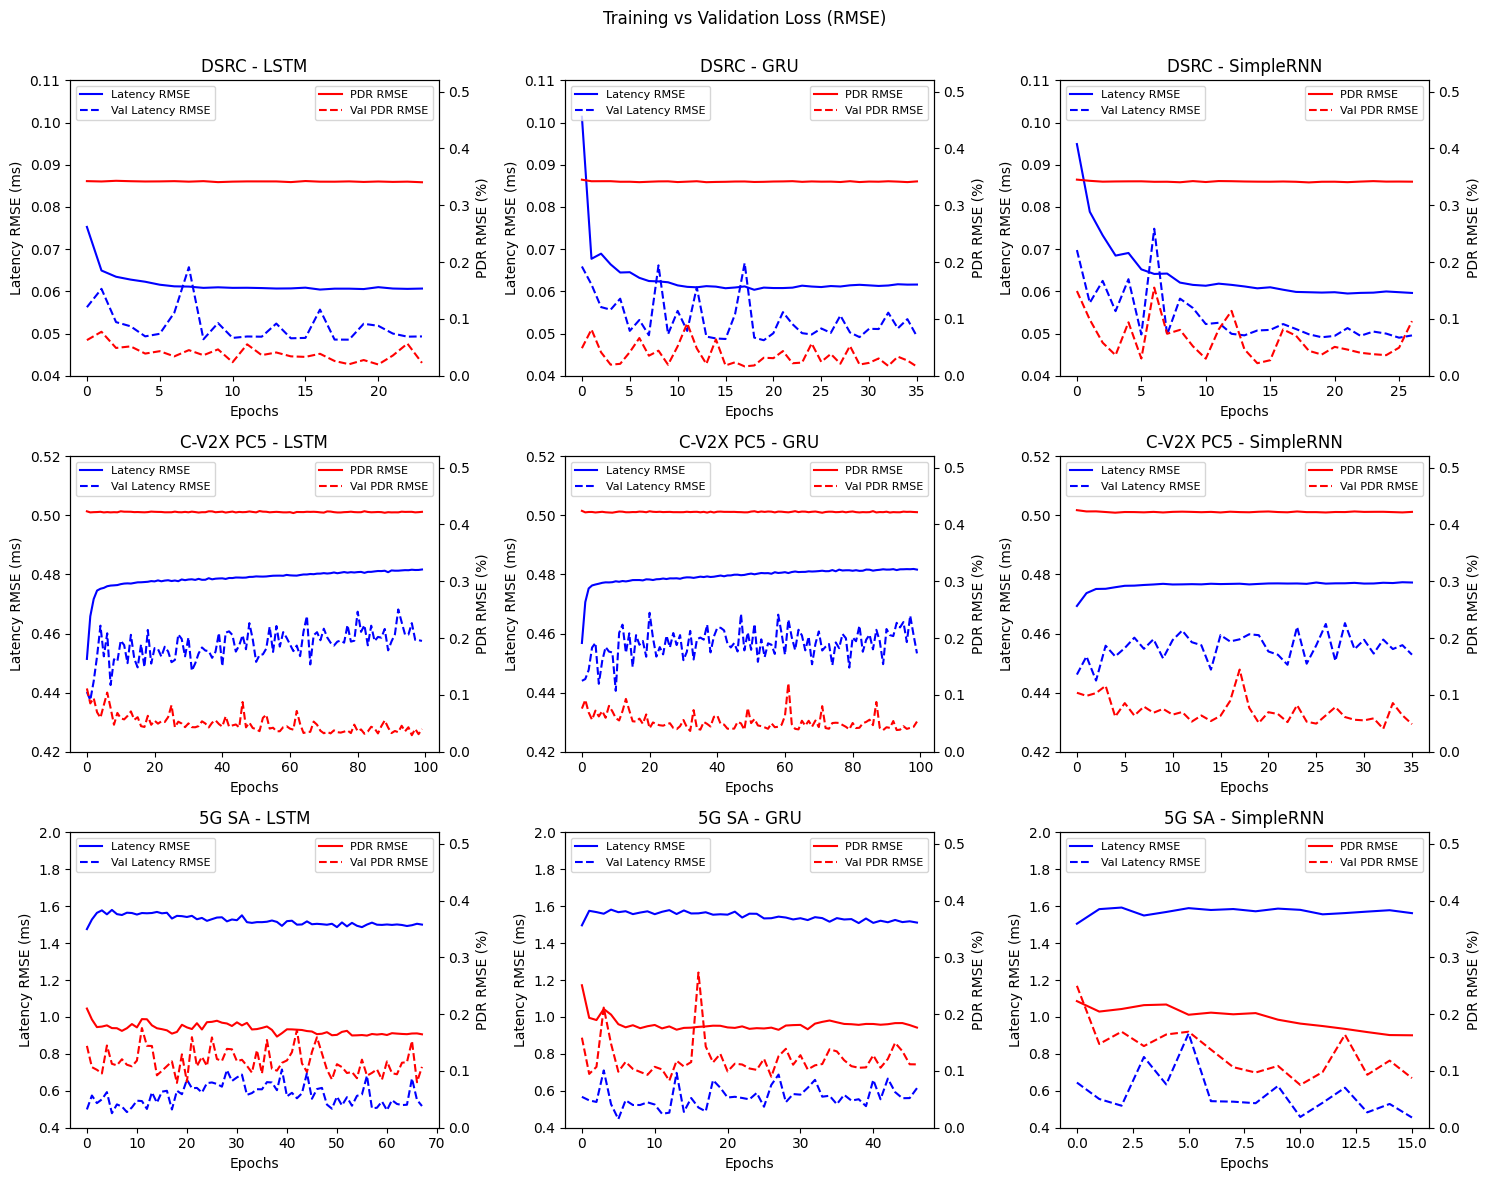

In [7]:
    # Plot losses
plot_losses(TYPES, RATS)